# 📊 Exploratory Data Analysis (EDA) - CIFAR Dataset

**ResNet Optimization Research Project**

Notebook ini berisi analisis eksplorasi data yang komprehensif untuk dataset CIFAR-10 dan CIFAR-100.

## Daftar Isi
1. [Setup dan Import Library](#1-setup)
2. [Load Dataset](#2-load-dataset)
3. [Statistik Dasar](#3-statistik-dasar)
4. [Distribusi Kelas](#4-distribusi-kelas)
5. [Visualisasi Sampel](#5-visualisasi-sampel)
6. [Analisis Pixel dan Warna](#6-analisis-pixel)
7. [Statistik Per Kelas](#7-statistik-per-kelas)
8. [Visualisasi Augmentasi](#8-augmentasi)
9. [T-SNE Visualization](#9-tsne)
10. [Data Quality Check](#10-quality-check)
11. [Kesimpulan](#11-kesimpulan)

## 1. Setup dan Import Library <a id='1-setup'></a>

In [2]:
# Import libraries
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings

# PyTorch
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

# Sklearn for analysis
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# Settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Add parent directory to path
sys.path.append(os.path.dirname(os.path.abspath('')))

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.5.1+cu121
Torchvision version: 0.20.1+cu121
CUDA available: True
CUDA device: NVIDIA GeForce RTX 3050 6GB Laptop GPU


## 2. Load Dataset <a id='2-load-dataset'></a>

In [3]:
# Configuration
DATA_DIR = '../data'
DATASET_NAME = 'cifar10'  # Change to 'cifar100' for CIFAR-100

# Basic transform (no augmentation for EDA)
basic_transform = transforms.Compose([
    transforms.ToTensor()
])

# Load CIFAR-10
if DATASET_NAME == 'cifar10':
    train_dataset = torchvision.datasets.CIFAR10(
        root=DATA_DIR, train=True, download=True, transform=basic_transform
    )
    test_dataset = torchvision.datasets.CIFAR10(
        root=DATA_DIR, train=False, download=True, transform=basic_transform
    )
    class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
                   'dog', 'frog', 'horse', 'ship', 'truck']
else:
    train_dataset = torchvision.datasets.CIFAR100(
        root=DATA_DIR, train=True, download=True, transform=basic_transform
    )
    test_dataset = torchvision.datasets.CIFAR100(
        root=DATA_DIR, train=False, download=True, transform=basic_transform
    )
    class_names = train_dataset.classes

print(f"Dataset: {DATASET_NAME.upper()}")
print(f"Number of classes: {len(class_names)}")
print(f"Training samples: {len(train_dataset):,}")
print(f"Test samples: {len(test_dataset):,}")
print(f"Total samples: {len(train_dataset) + len(test_dataset):,}")

100%|██████████| 170M/170M [00:33<00:00, 5.04MB/s] 


Extracting ../data\cifar-10-python.tar.gz to ../data
Files already downloaded and verified
Dataset: CIFAR10
Number of classes: 10
Training samples: 50,000
Test samples: 10,000
Total samples: 60,000


In [4]:
# Extract all data for analysis
print("Extracting training data...")
train_images = []
train_labels = []

for img, label in train_dataset:
    train_images.append(img.numpy())
    train_labels.append(label)

train_images = np.array(train_images)
train_labels = np.array(train_labels)

print("Extracting test data...")
test_images = []
test_labels = []

for img, label in test_dataset:
    test_images.append(img.numpy())
    test_labels.append(label)

test_images = np.array(test_images)
test_labels = np.array(test_labels)

print(f"\nTrain images shape: {train_images.shape}")
print(f"Test images shape: {test_images.shape}")
print(f"Image dimensions: {train_images.shape[2]}x{train_images.shape[3]} pixels")
print(f"Channels: {train_images.shape[1]} (RGB)")

Extracting training data...
Extracting test data...

Train images shape: (50000, 3, 32, 32)
Test images shape: (10000, 3, 32, 32)
Image dimensions: 32x32 pixels
Channels: 3 (RGB)


## 3. Statistik Dasar <a id='3-statistik-dasar'></a>

In [10]:
# Basic statistics
print("="*60)
print("STATISTIK DASAR DATASET")
print("="*60)

# Image statistics
print(f"\nImage Statistics (Training Set):")
print(f"   Min pixel value: {train_images.min():.4f}")
print(f"   Max pixel value: {train_images.max():.4f}")
print(f"   Mean pixel value: {train_images.mean():.4f}")
print(f"   Std pixel value: {train_images.std():.4f}")

# Per-channel statistics
print(f"\nPer-Channel Statistics (Training Set):")
channel_names = ['Red', 'Green', 'Blue']
for i, name in enumerate(channel_names):
    channel_data = train_images[:, i, :, :]
    print(f"   {name}:")
    print(f"      Mean: {channel_data.mean():.4f}")
    print(f"      Std:  {channel_data.std():.4f}")

# Memory size
train_size_mb = train_images.nbytes / (1024 * 1024)
test_size_mb = test_images.nbytes / (1024 * 1024)
print(f"\nMemory Usage:")
print(f"   Training set: {train_size_mb:.2f} MB")
print(f"   Test set: {test_size_mb:.2f} MB")
print(f"   Total: {train_size_mb + test_size_mb:.2f} MB")

STATISTIK DASAR DATASET

Image Statistics (Training Set):
   Min pixel value: 0.0000
   Max pixel value: 1.0000
   Mean pixel value: 0.4734
   Std pixel value: 0.2516

Per-Channel Statistics (Training Set):
   Red:
      Mean: 0.4914
      Std:  0.2470
   Green:
      Mean: 0.4822
      Std:  0.2435
   Blue:
      Mean: 0.4465
      Std:  0.2616

Memory Usage:
   Training set: 585.94 MB
   Test set: 117.19 MB
   Total: 703.12 MB


In [6]:
# Create summary DataFrame
summary_data = {
    'Metric': ['Total Training Samples', 'Total Test Samples', 'Number of Classes',
               'Image Height', 'Image Width', 'Channels',
               'Mean (R)', 'Mean (G)', 'Mean (B)',
               'Std (R)', 'Std (G)', 'Std (B)'],
    'Value': [
        len(train_dataset), len(test_dataset), len(class_names),
        train_images.shape[2], train_images.shape[3], train_images.shape[1],
        f"{train_images[:, 0].mean():.4f}",
        f"{train_images[:, 1].mean():.4f}",
        f"{train_images[:, 2].mean():.4f}",
        f"{train_images[:, 0].std():.4f}",
        f"{train_images[:, 1].std():.4f}",
        f"{train_images[:, 2].std():.4f}"
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df.style.set_properties(**{'text-align': 'left'})

,Metric,Value
0,Total Training Samples,50000
1,Total Test Samples,10000
2,Number of Classes,10
3,Image Height,32
4,Image Width,32
5,Channels,3
6,Mean (R),0.4914
7,Mean (G),0.4822
8,Mean (B),0.4465
9,Std (R),0.2470


## 4. Distribusi Kelas <a id='4-distribusi-kelas'></a>

In [9]:
# Class distribution
train_class_counts = Counter(train_labels)
test_class_counts = Counter(test_labels)

# Create DataFrame
class_dist_df = pd.DataFrame({
    'Class': class_names,
    'Train Count': [train_class_counts[i] for i in range(len(class_names))],
    'Test Count': [test_class_counts[i] for i in range(len(class_names))],
})
class_dist_df['Train %'] = (class_dist_df['Train Count'] / len(train_labels) * 100).round(2)
class_dist_df['Test %'] = (class_dist_df['Test Count'] / len(test_labels) * 100).round(2)
class_dist_df['Total'] = class_dist_df['Train Count'] + class_dist_df['Test Count']

print("Class Distribution:")
class_dist_df

Class Distribution:


,Class,Train Count,Test Count,Train %,Test %,Total
0,airplane,5000,1000,10.0,10.0,6000
1,automobile,5000,1000,10.0,10.0,6000
2,bird,5000,1000,10.0,10.0,6000
3,cat,5000,1000,10.0,10.0,6000
4,deer,5000,1000,10.0,10.0,6000
5,dog,5000,1000,10.0,10.0,6000
6,frog,5000,1000,10.0,10.0,6000
7,horse,5000,1000,10.0,10.0,6000
8,ship,5000,1000,10.0,10.0,6000
9,truck,5000,1000,10.0,10.0,6000


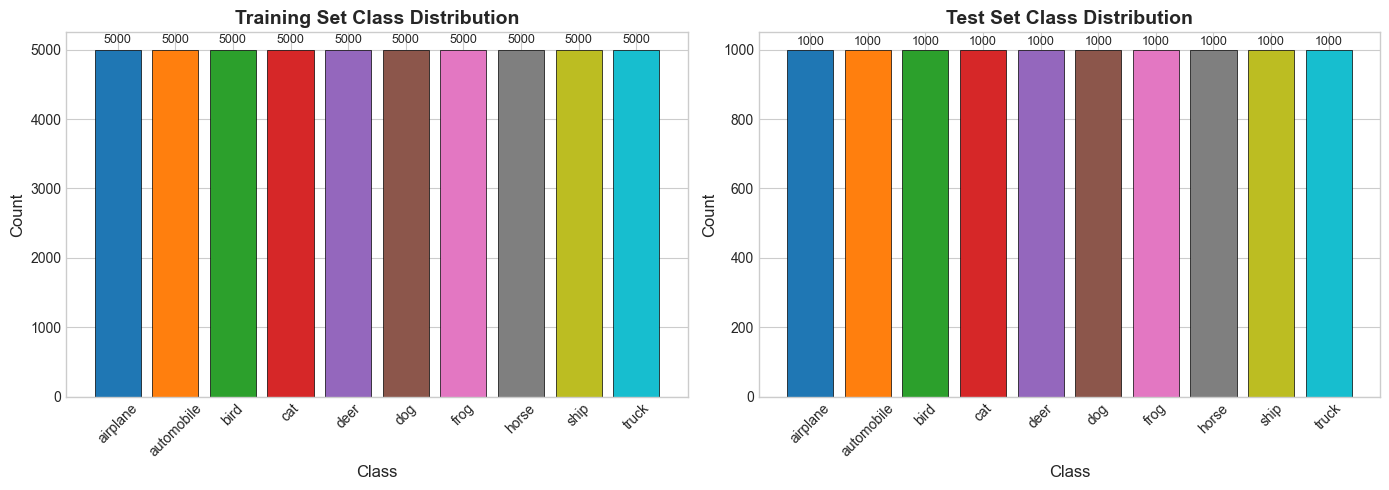

Figure saved to: experiments/results/class_distribution.png


In [11]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set distribution
colors = plt.cm.tab10(np.linspace(0, 1, len(class_names)))
bars1 = axes[0].bar(class_names, class_dist_df['Train Count'], color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Class', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Training Set Class Distribution', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Add value labels
for bar, count in zip(bars1, class_dist_df['Train Count']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
                 str(count), ha='center', va='bottom', fontsize=9)

# Test set distribution
bars2 = axes[1].bar(class_names, class_dist_df['Test Count'], color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('Class', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Test Set Class Distribution', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

# Add value labels
for bar, count in zip(bars2, class_dist_df['Test Count']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                 str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../experiments/results/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved to: experiments/results/class_distribution.png")

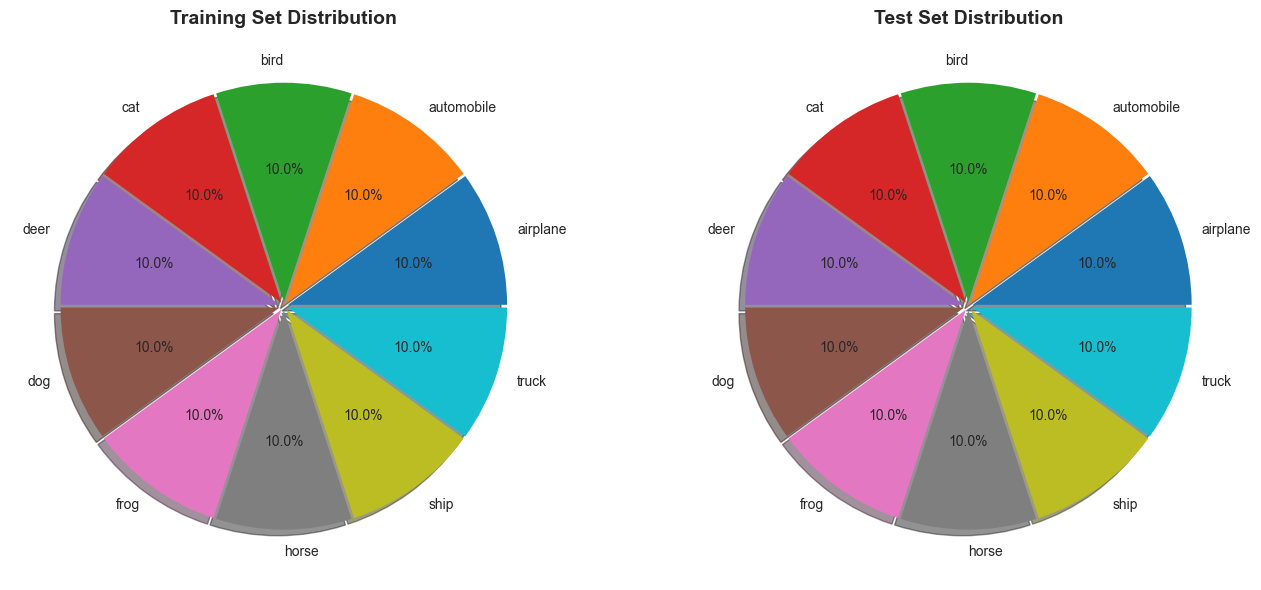

In [12]:
# Pie chart for class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Training set
wedges1, texts1, autotexts1 = axes[0].pie(
    class_dist_df['Train Count'], 
    labels=class_names, 
    autopct='%1.1f%%',
    colors=colors,
    explode=[0.02]*len(class_names),
    shadow=True
)
axes[0].set_title('Training Set Distribution', fontsize=14, fontweight='bold')

# Test set
wedges2, texts2, autotexts2 = axes[1].pie(
    class_dist_df['Test Count'], 
    labels=class_names, 
    autopct='%1.1f%%',
    colors=colors,
    explode=[0.02]*len(class_names),
    shadow=True
)
axes[1].set_title('Test Set Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../experiments/results/class_distribution_pie.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Check class balance
train_counts = list(train_class_counts.values())
imbalance_ratio = max(train_counts) / min(train_counts)

print(f"\n Class Balance Analysis:")
print(f"   Maximum samples per class: {max(train_counts):,}")
print(f"   Minimum samples per class: {min(train_counts):,}")
print(f"   Imbalance ratio: {imbalance_ratio:.2f}")

if imbalance_ratio == 1.0:
    print(f"    Dataset is PERFECTLY BALANCED!")
elif imbalance_ratio < 1.5:
    print(f"    Dataset is well balanced (ratio < 1.5)")
elif imbalance_ratio < 3.0:
    print(f"    Dataset is slightly imbalanced (ratio < 3.0)")
else:
    print(f"    Dataset is significantly imbalanced (ratio >= 3.0)")


 Class Balance Analysis:
   Maximum samples per class: 5,000
   Minimum samples per class: 5,000
   Imbalance ratio: 1.00
    Dataset is PERFECTLY BALANCED!


## 5. Visualisasi Sampel <a id='5-visualisasi-sampel'></a>

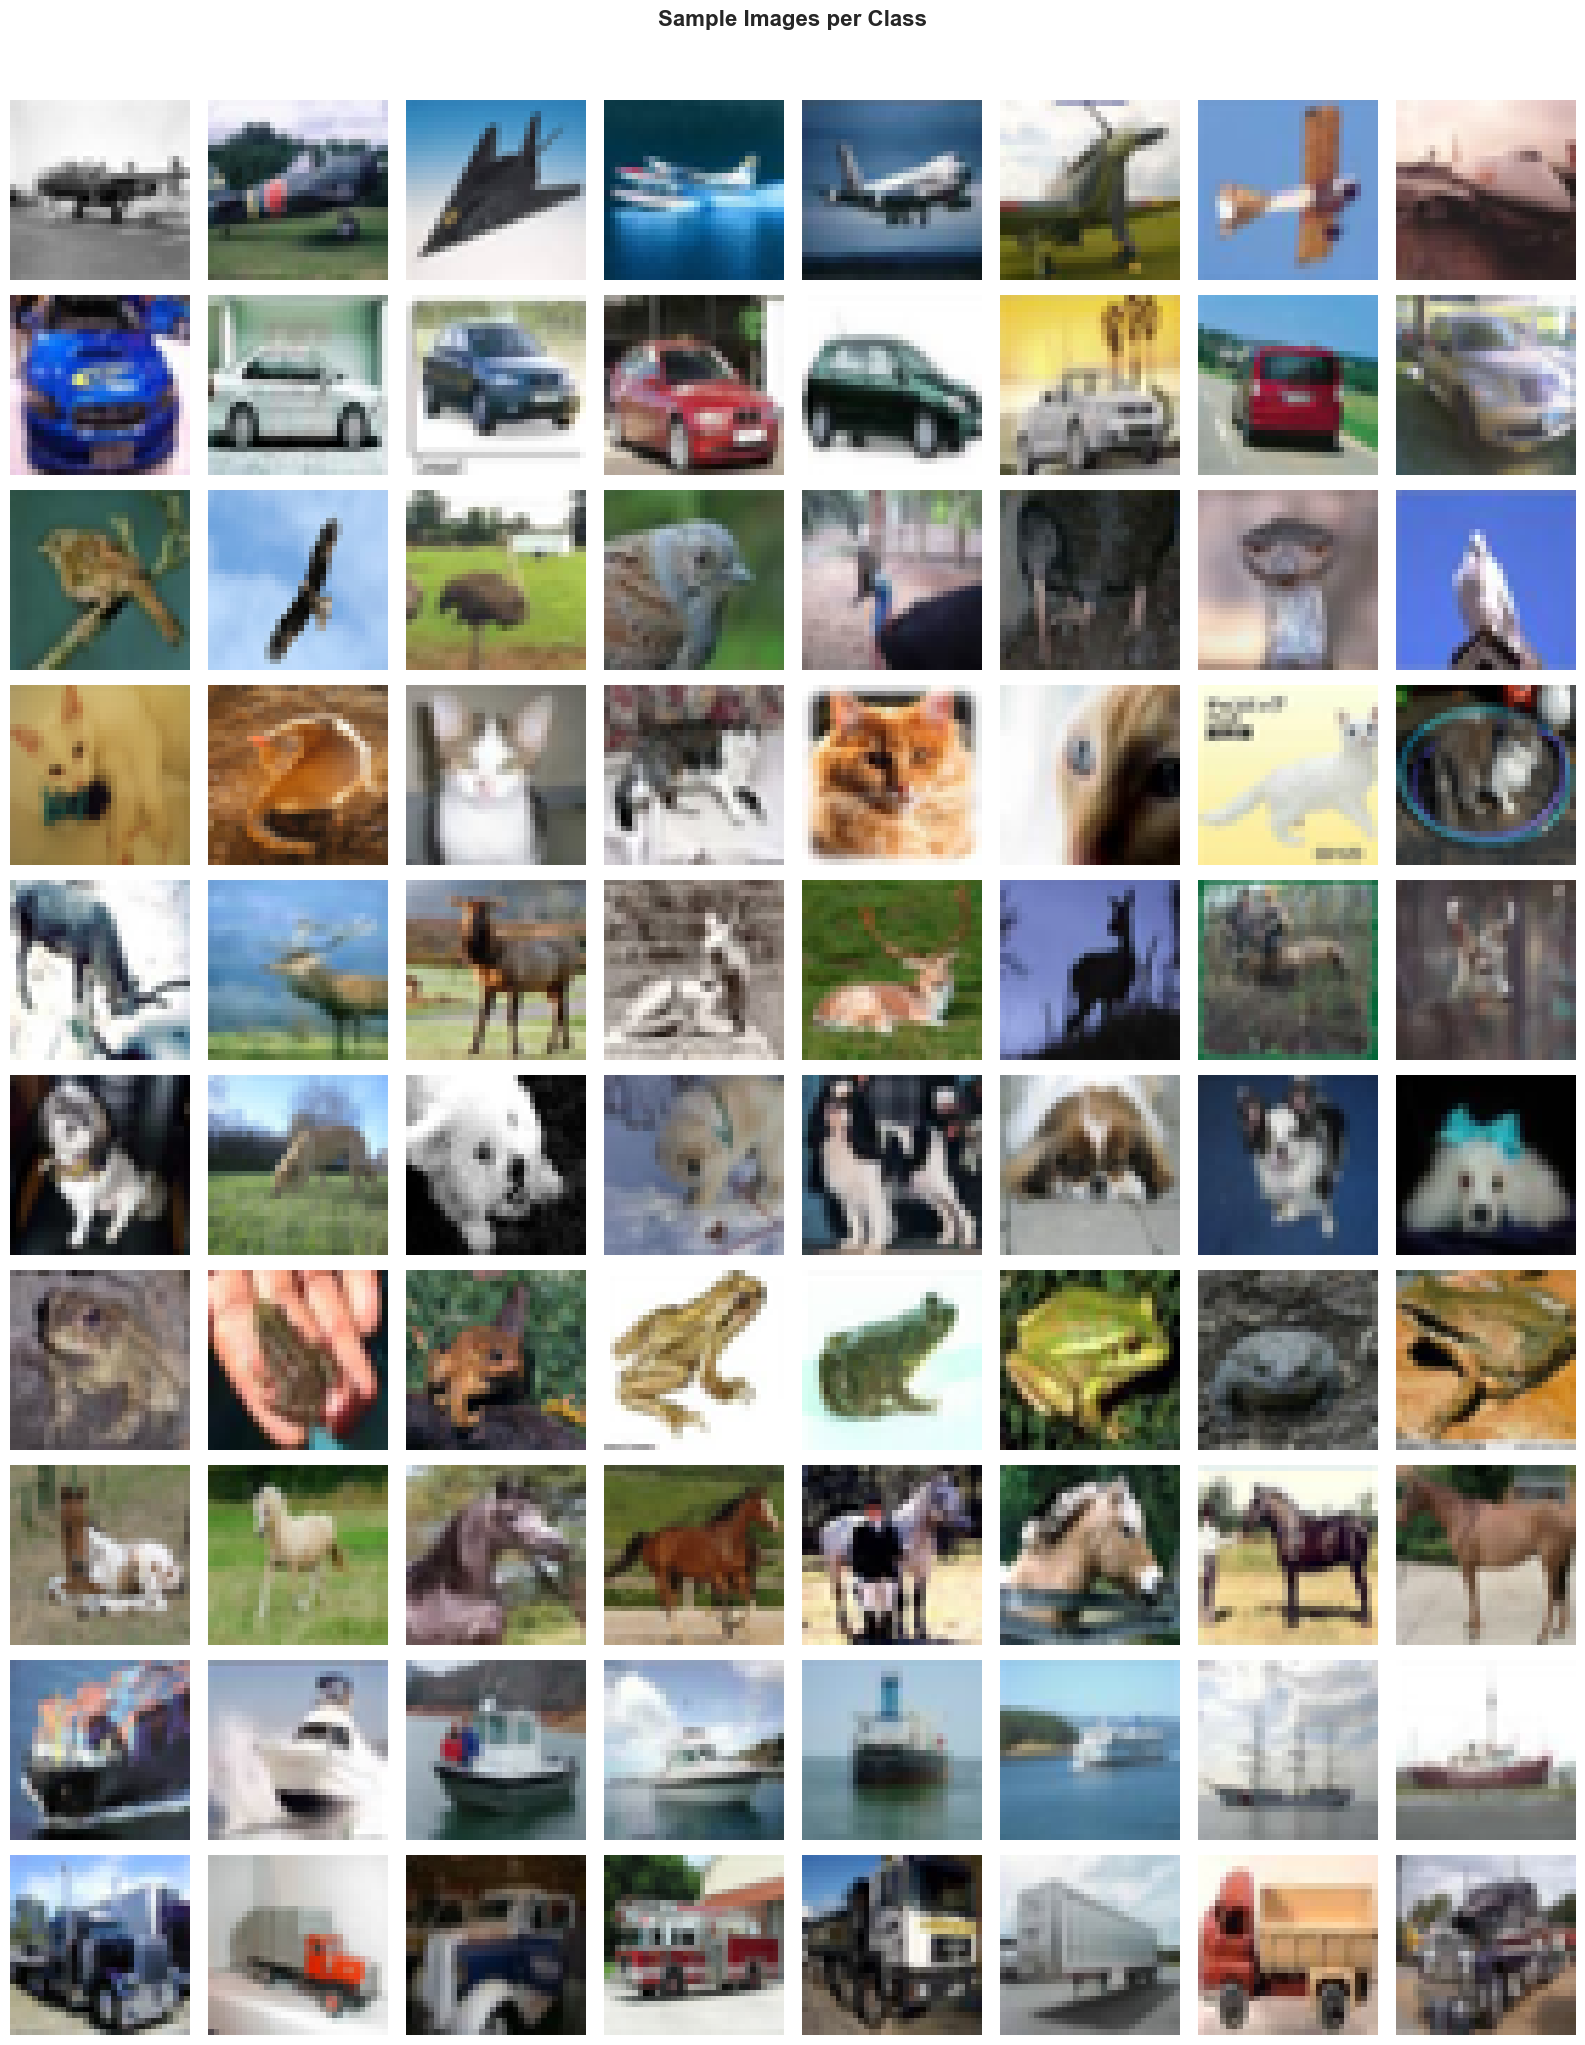

Figure saved to: experiments/results/sample_images_per_class.png


In [15]:
# Show sample images from each class
def show_samples_per_class(images, labels, class_names, samples_per_class=5):
    """Display sample images from each class."""
    n_classes = len(class_names)
    fig, axes = plt.subplots(n_classes, samples_per_class, figsize=(samples_per_class * 2, n_classes * 2))
    
    for class_idx in range(n_classes):
        # Get indices of this class
        class_indices = np.where(labels == class_idx)[0]
        # Random sample
        sample_indices = np.random.choice(class_indices, samples_per_class, replace=False)
        
        for j, idx in enumerate(sample_indices):
            img = images[idx].transpose(1, 2, 0)  # CHW -> HWC
            axes[class_idx, j].imshow(img)
            axes[class_idx, j].axis('off')
            if j == 0:
                axes[class_idx, j].set_ylabel(class_names[class_idx], fontsize=10, rotation=0, 
                                              labelpad=50, va='center')
    
    plt.suptitle('Sample Images per Class', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('../experiments/results/sample_images_per_class.png', dpi=150, bbox_inches='tight')
    plt.show()

show_samples_per_class(train_images, train_labels, class_names, samples_per_class=8)
print("Figure saved to: experiments/results/sample_images_per_class.png")

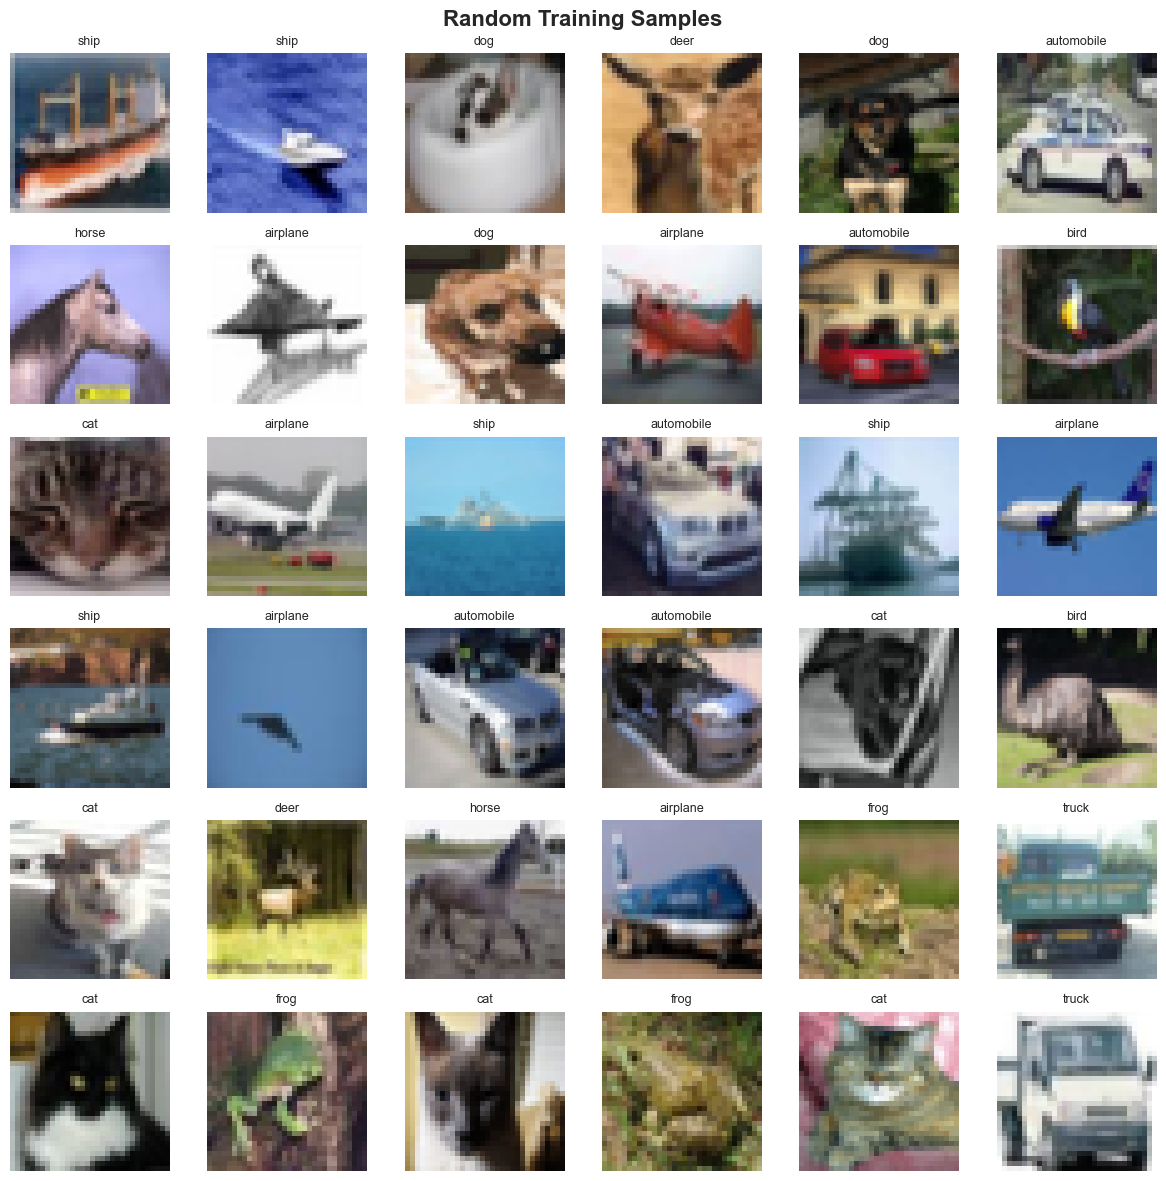

 Figure saved to: experiments/results/random_samples.png


In [16]:
# Show random samples in a grid
def show_random_samples(images, labels, class_names, n_samples=36):
    """Display random sample images."""
    n_rows = int(np.sqrt(n_samples))
    n_cols = int(np.ceil(n_samples / n_rows))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 2))
    axes = axes.flatten()
    
    indices = np.random.choice(len(images), n_samples, replace=False)
    
    for ax, idx in zip(axes, indices):
        img = images[idx].transpose(1, 2, 0)
        ax.imshow(img)
        ax.set_title(class_names[labels[idx]], fontsize=9)
        ax.axis('off')
    
    plt.suptitle('Random Training Samples', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../experiments/results/random_samples.png', dpi=150, bbox_inches='tight')
    plt.show()

show_random_samples(train_images, train_labels, class_names, n_samples=36)
print(" Figure saved to: experiments/results/random_samples.png")

## 6. Analisis Pixel dan Warna <a id='6-analisis-pixel'></a>

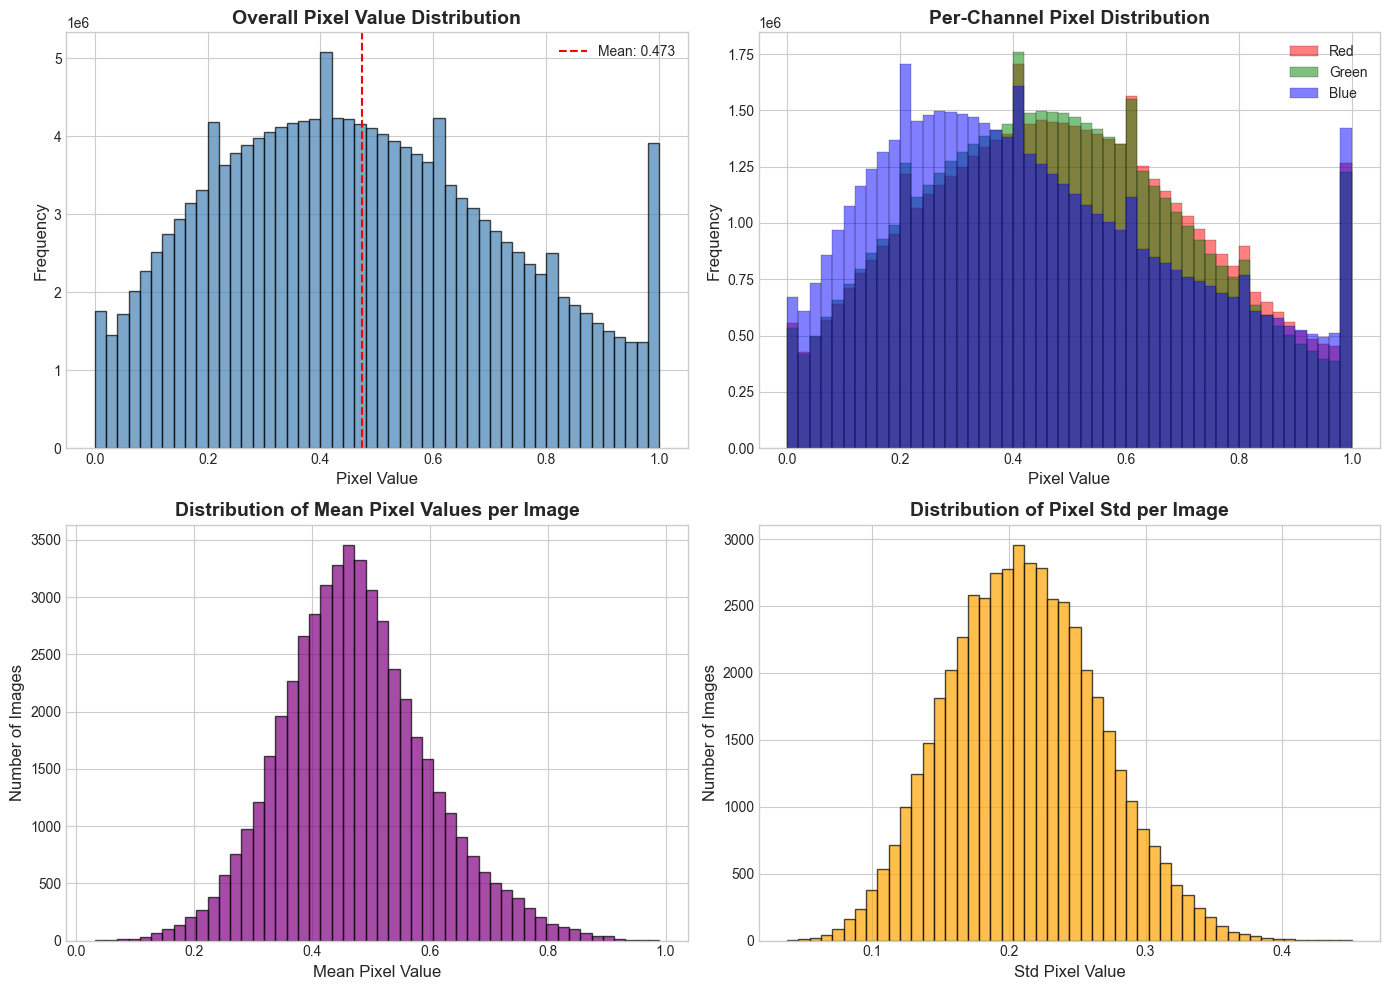

Figure saved to: experiments/results/pixel_distribution.png


In [17]:
# Pixel value distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Overall pixel distribution
axes[0, 0].hist(train_images.flatten(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Pixel Value', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Overall Pixel Value Distribution', fontsize=14, fontweight='bold')
axes[0, 0].axvline(train_images.mean(), color='red', linestyle='--', label=f'Mean: {train_images.mean():.3f}')
axes[0, 0].legend()

# Per-channel distribution
channel_colors = ['red', 'green', 'blue']
for i, (name, color) in enumerate(zip(channel_names, channel_colors)):
    channel_data = train_images[:, i, :, :].flatten()
    axes[0, 1].hist(channel_data, bins=50, color=color, alpha=0.5, label=name, edgecolor='black', linewidth=0.3)

axes[0, 1].set_xlabel('Pixel Value', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].set_title('Per-Channel Pixel Distribution', fontsize=14, fontweight='bold')
axes[0, 1].legend()

# Mean intensity per image
mean_intensities = train_images.mean(axis=(1, 2, 3))
axes[1, 0].hist(mean_intensities, bins=50, color='purple', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Mean Pixel Value', fontsize=12)
axes[1, 0].set_ylabel('Number of Images', fontsize=12)
axes[1, 0].set_title('Distribution of Mean Pixel Values per Image', fontsize=14, fontweight='bold')

# Standard deviation per image
std_intensities = train_images.std(axis=(1, 2, 3))
axes[1, 1].hist(std_intensities, bins=50, color='orange', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Std Pixel Value', fontsize=12)
axes[1, 1].set_ylabel('Number of Images', fontsize=12)
axes[1, 1].set_title('Distribution of Pixel Std per Image', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../experiments/results/pixel_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved to: experiments/results/pixel_distribution.png")

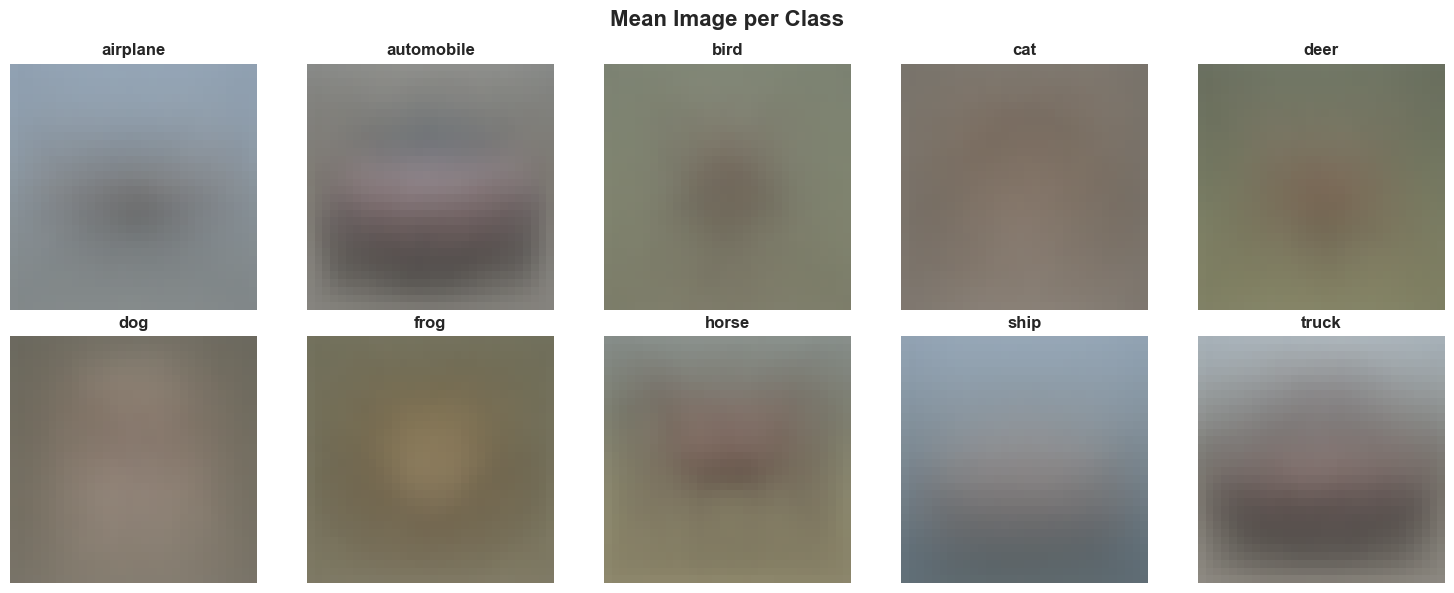

Figure saved to: experiments/results/mean_images_per_class.png


In [18]:
# Color analysis - Average image per class
def compute_mean_image_per_class(images, labels, n_classes):
    """Compute mean image for each class."""
    mean_images = []
    for class_idx in range(n_classes):
        class_mask = labels == class_idx
        class_images = images[class_mask]
        mean_img = class_images.mean(axis=0)
        mean_images.append(mean_img)
    return np.array(mean_images)

mean_images = compute_mean_image_per_class(train_images, train_labels, len(class_names))

# Plot mean images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, (ax, class_name) in enumerate(zip(axes, class_names)):
    mean_img = mean_images[i].transpose(1, 2, 0)  # CHW -> HWC
    ax.imshow(mean_img)
    ax.set_title(class_name, fontsize=12, fontweight='bold')
    ax.axis('off')

plt.suptitle('Mean Image per Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../experiments/results/mean_images_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved to: experiments/results/mean_images_per_class.png")

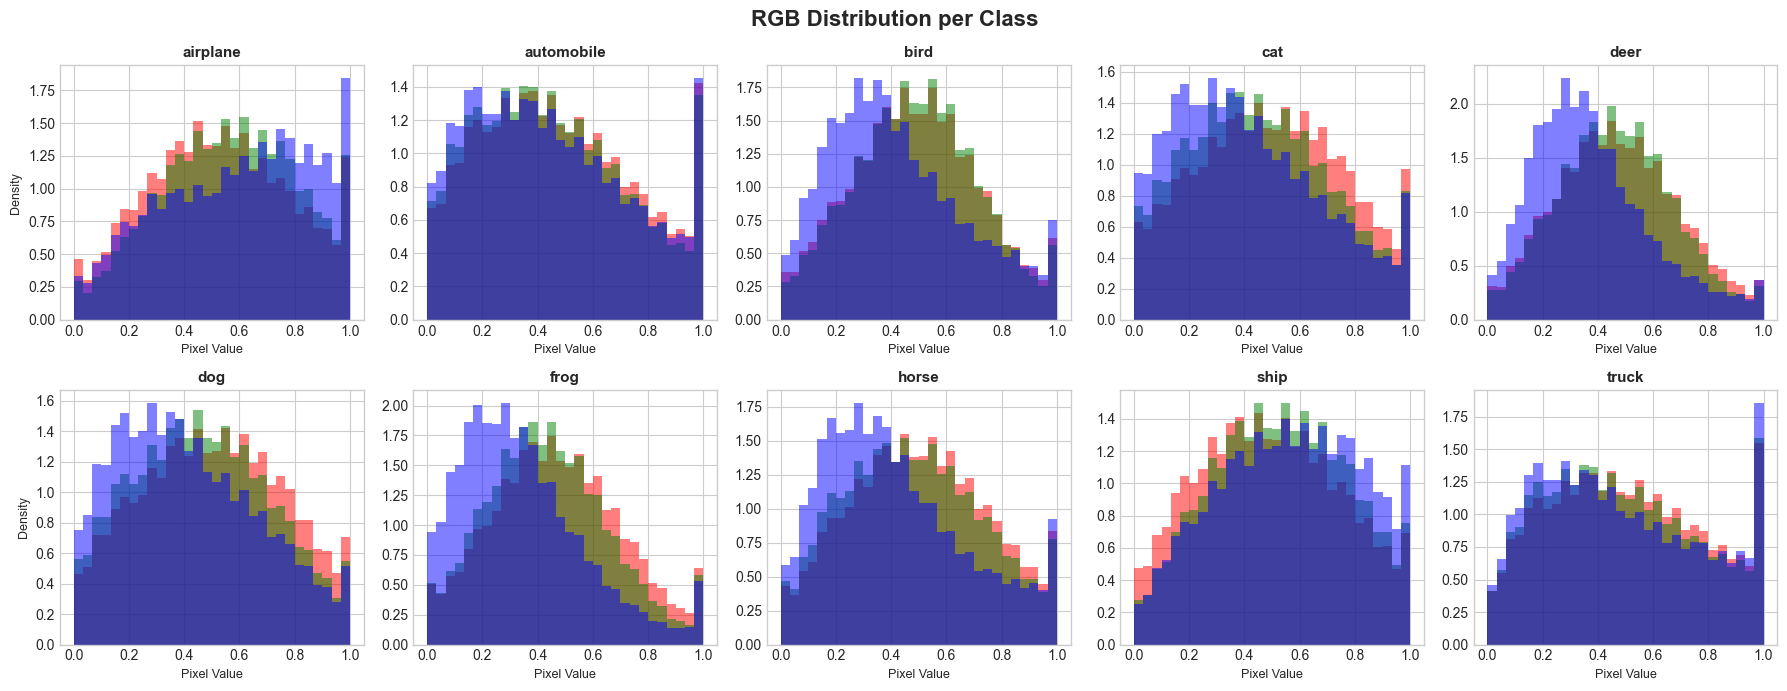

 Figure saved to: experiments/results/rgb_distribution_per_class.png


In [19]:
# Color histogram per class
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for class_idx, (ax, class_name) in enumerate(zip(axes, class_names)):
    class_images = train_images[train_labels == class_idx]
    
    for ch, color in enumerate(['red', 'green', 'blue']):
        channel_data = class_images[:, ch, :, :].flatten()
        ax.hist(channel_data, bins=30, color=color, alpha=0.5, density=True)
    
    ax.set_title(class_name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Pixel Value', fontsize=9)
    if class_idx % 5 == 0:
        ax.set_ylabel('Density', fontsize=9)

plt.suptitle('RGB Distribution per Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../experiments/results/rgb_distribution_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Figure saved to: experiments/results/rgb_distribution_per_class.png")

## 7. Statistik Per Kelas <a id='7-statistik-per-kelas'></a>

In [20]:
# Compute statistics per class
class_stats = []

for class_idx in range(len(class_names)):
    class_images = train_images[train_labels == class_idx]
    
    stats = {
        'Class': class_names[class_idx],
        'Count': len(class_images),
        'Mean (R)': class_images[:, 0].mean(),
        'Mean (G)': class_images[:, 1].mean(),
        'Mean (B)': class_images[:, 2].mean(),
        'Std (R)': class_images[:, 0].std(),
        'Std (G)': class_images[:, 1].std(),
        'Std (B)': class_images[:, 2].std(),
        'Brightness': class_images.mean(),
        'Contrast': class_images.std()
    }
    class_stats.append(stats)

class_stats_df = pd.DataFrame(class_stats)
class_stats_df = class_stats_df.round(4)

print("Per-Class Statistics:")
class_stats_df

Per-Class Statistics:


,Class,Count,Mean (R),Mean (G),Mean (B),Std (R),Std (G),Std (B),Brightness,Contrast
0,airplane,5000,0.5257,0.5603,0.5889,0.2502,0.2408,0.2660,0.5583,0.2539
1,automobile,5000,0.4712,0.4545,0.4472,0.2681,0.2658,0.2749,0.4576,0.2698
2,bird,5000,0.4892,0.4915,0.4240,0.2271,0.2209,0.2434,0.4683,0.2328
3,cat,5000,0.4955,0.4564,0.4155,0.2568,0.2523,0.2580,0.4558,0.2578
4,deer,5000,0.4716,0.4652,0.3782,0.2173,0.2065,0.2118,0.4383,0.2162
5,dog,5000,0.4999,0.4646,0.4165,0.2504,0.2437,0.2489,0.4604,0.2501
6,frog,5000,0.4701,0.4384,0.3452,0.2289,0.2186,0.2204,0.4179,0.2289
7,horse,5000,0.5020,0.4799,0.4169,0.2430,0.2440,0.2517,0.4662,0.2489
8,ship,5000,0.4902,0.5254,0.5547,0.2496,0.2407,0.2515,0.5234,0.2487
9,truck,5000,0.4987,0.4853,0.4781,0.2681,0.2691,0.2810,0.4874,0.2729


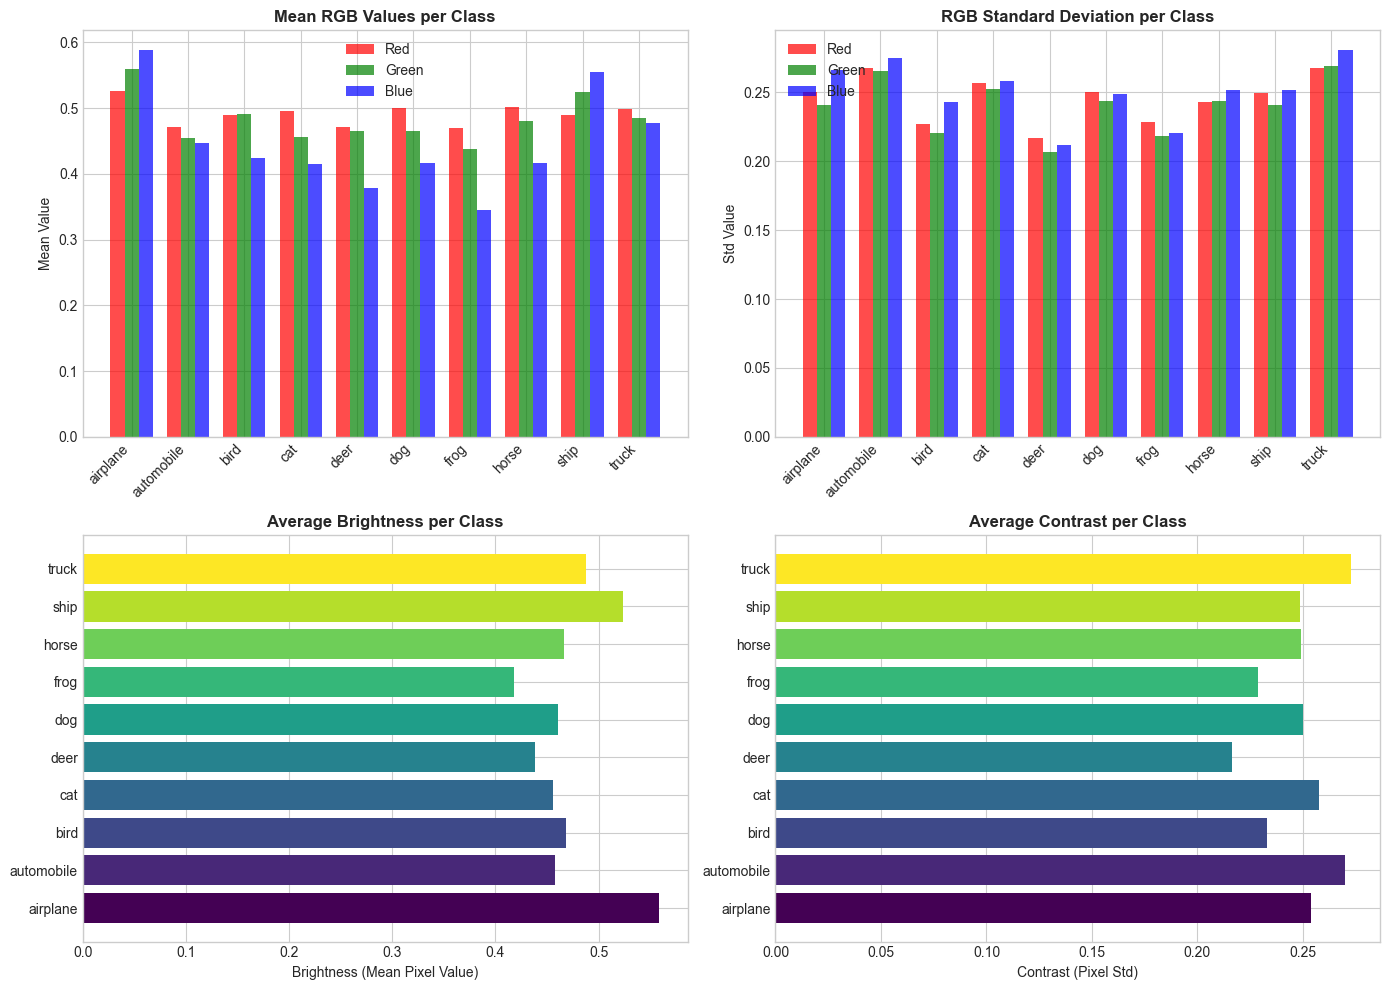

Figure saved to: experiments/results/per_class_statistics.png


In [21]:
# Visualize per-class statistics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Mean RGB values
x = np.arange(len(class_names))
width = 0.25

axes[0, 0].bar(x - width, class_stats_df['Mean (R)'], width, label='Red', color='red', alpha=0.7)
axes[0, 0].bar(x, class_stats_df['Mean (G)'], width, label='Green', color='green', alpha=0.7)
axes[0, 0].bar(x + width, class_stats_df['Mean (B)'], width, label='Blue', color='blue', alpha=0.7)
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(class_names, rotation=45, ha='right')
axes[0, 0].set_ylabel('Mean Value')
axes[0, 0].set_title('Mean RGB Values per Class', fontweight='bold')
axes[0, 0].legend()

# Std RGB values
axes[0, 1].bar(x - width, class_stats_df['Std (R)'], width, label='Red', color='red', alpha=0.7)
axes[0, 1].bar(x, class_stats_df['Std (G)'], width, label='Green', color='green', alpha=0.7)
axes[0, 1].bar(x + width, class_stats_df['Std (B)'], width, label='Blue', color='blue', alpha=0.7)
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(class_names, rotation=45, ha='right')
axes[0, 1].set_ylabel('Std Value')
axes[0, 1].set_title('RGB Standard Deviation per Class', fontweight='bold')
axes[0, 1].legend()

# Brightness per class
colors = plt.cm.viridis(np.linspace(0, 1, len(class_names)))
axes[1, 0].barh(class_names, class_stats_df['Brightness'], color=colors)
axes[1, 0].set_xlabel('Brightness (Mean Pixel Value)')
axes[1, 0].set_title('Average Brightness per Class', fontweight='bold')

# Contrast per class
axes[1, 1].barh(class_names, class_stats_df['Contrast'], color=colors)
axes[1, 1].set_xlabel('Contrast (Pixel Std)')
axes[1, 1].set_title('Average Contrast per Class', fontweight='bold')

plt.tight_layout()
plt.savefig('../experiments/results/per_class_statistics.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved to: experiments/results/per_class_statistics.png")

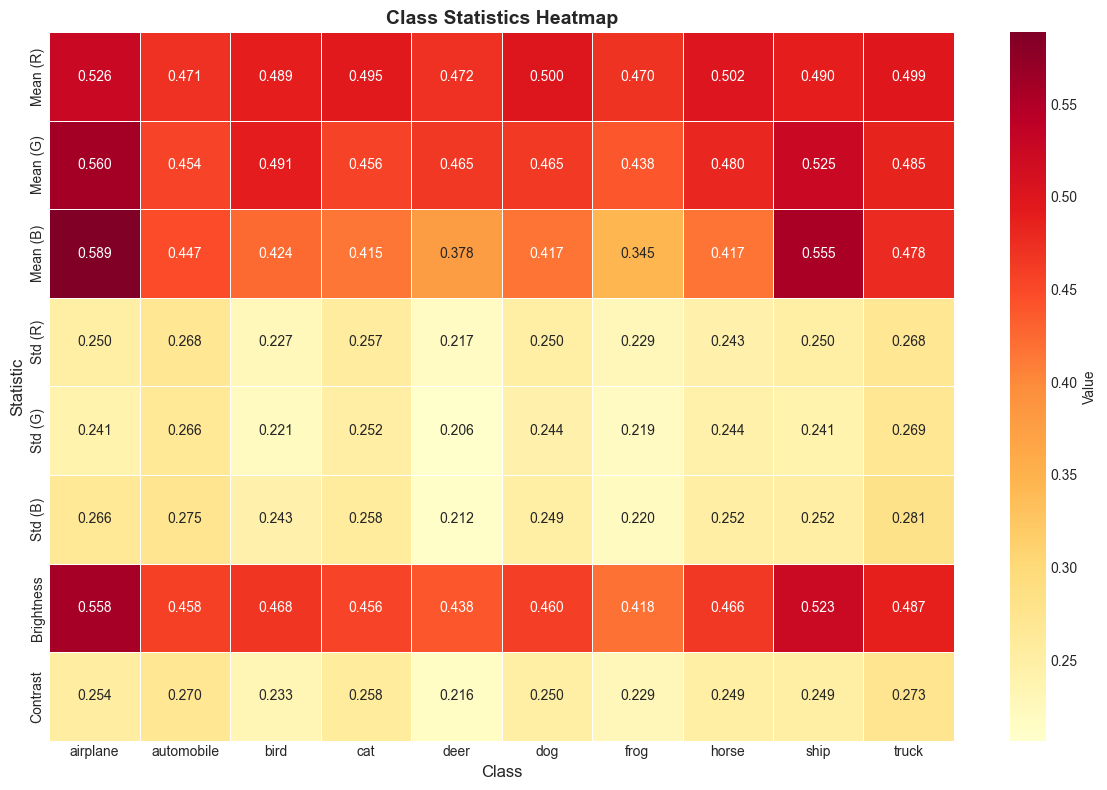

Figure saved to: experiments/results/class_statistics_heatmap.png


In [22]:
# Heatmap of class statistics
stats_for_heatmap = class_stats_df[['Mean (R)', 'Mean (G)', 'Mean (B)', 'Std (R)', 'Std (G)', 'Std (B)', 'Brightness', 'Contrast']]
stats_for_heatmap.index = class_stats_df['Class']

plt.figure(figsize=(12, 8))
sns.heatmap(stats_for_heatmap.T, annot=True, fmt='.3f', cmap='YlOrRd', 
            linewidths=0.5, cbar_kws={'label': 'Value'})
plt.title('Class Statistics Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Class', fontsize=12)
plt.ylabel('Statistic', fontsize=12)
plt.tight_layout()
plt.savefig('../experiments/results/class_statistics_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved to: experiments/results/class_statistics_heatmap.png")

## 8. Visualisasi Augmentasi <a id='8-augmentasi'></a>

In [23]:
# Define augmentation transforms
from torchvision.transforms import autoaugment

augmentations = {
    'Original': transforms.Compose([transforms.ToTensor()]),
    'HorizontalFlip': transforms.Compose([
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor()
    ]),
    'RandomRotation': transforms.Compose([
        transforms.RandomRotation(15),
        transforms.ToTensor()
    ]),
    'ColorJitter': transforms.Compose([
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
        transforms.ToTensor()
    ]),
    'RandomCrop': transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor()
    ]),
    'AutoAugment': transforms.Compose([
        autoaugment.AutoAugment(policy=autoaugment.AutoAugmentPolicy.CIFAR10),
        transforms.ToTensor()
    ]),
    'RandAugment': transforms.Compose([
        autoaugment.RandAugment(num_ops=2, magnitude=9),
        transforms.ToTensor()
    ]),
    'GaussianBlur': transforms.Compose([
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
        transforms.ToTensor()
    ]),
}

print(f"Defined {len(augmentations)} augmentation types")

Defined 8 augmentation types


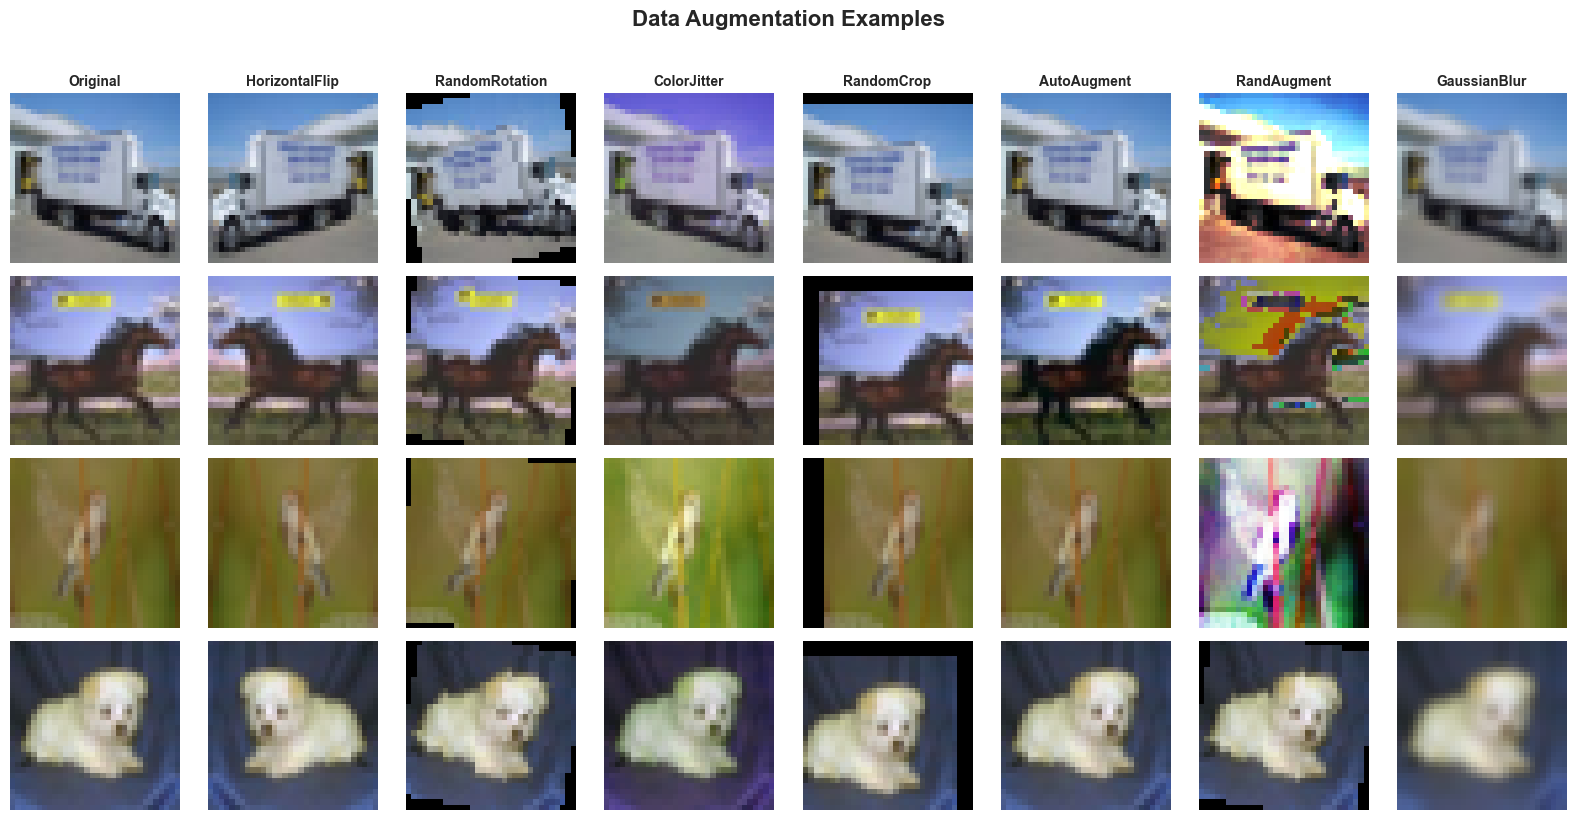

Figure saved to: experiments/results/augmentation_examples.png


In [24]:
# Visualize augmentations
from PIL import Image

# Select sample images
sample_indices = np.random.choice(len(train_dataset), 4, replace=False)

fig, axes = plt.subplots(4, len(augmentations), figsize=(len(augmentations) * 2, 4 * 2))

for row, idx in enumerate(sample_indices):
    # Get original PIL image
    original_img, label = train_dataset.data[idx], train_dataset.targets[idx]
    pil_img = Image.fromarray(original_img)
    
    for col, (aug_name, aug_transform) in enumerate(augmentations.items()):
        # Apply augmentation
        augmented = aug_transform(pil_img)
        img_np = augmented.numpy().transpose(1, 2, 0)
        
        axes[row, col].imshow(img_np)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(aug_name, fontsize=10, fontweight='bold')
        if col == 0:
            axes[row, col].set_ylabel(class_names[label], fontsize=10, rotation=0, 
                                       labelpad=40, va='center')

plt.suptitle('Data Augmentation Examples', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../experiments/results/augmentation_examples.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved to: experiments/results/augmentation_examples.png")

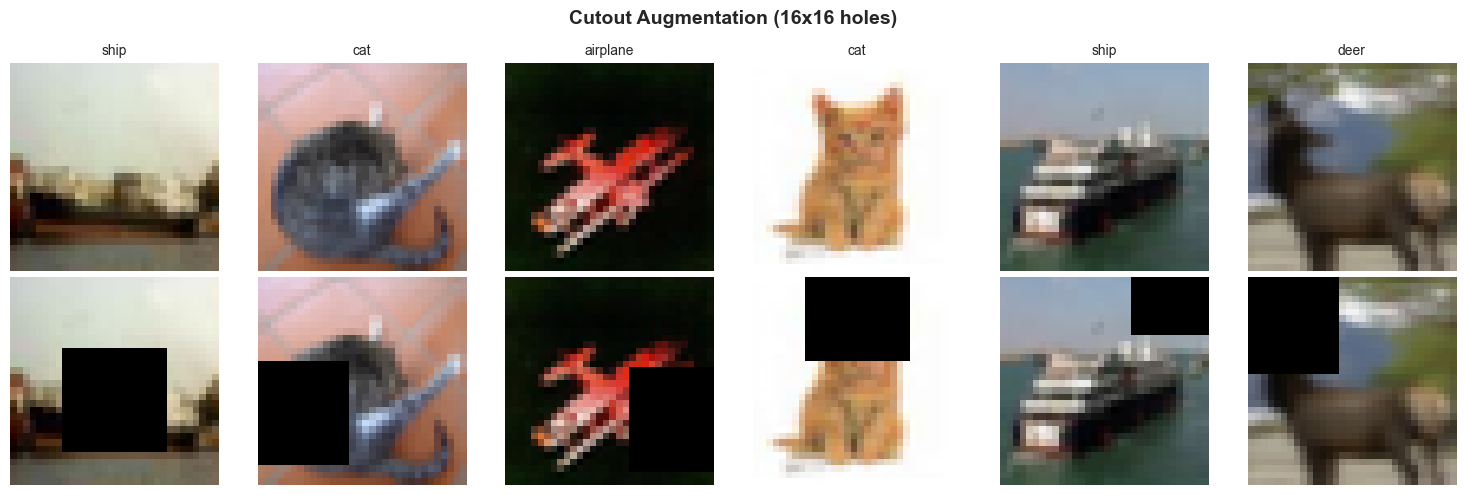

Figure saved to: experiments/results/cutout_examples.png


In [25]:
# Cutout visualization
class Cutout:
    """Cutout augmentation."""
    def __init__(self, n_holes=1, length=16):
        self.n_holes = n_holes
        self.length = length
    
    def __call__(self, img):
        h, w = img.shape[1], img.shape[2]
        mask = np.ones((h, w), np.float32)
        
        for _ in range(self.n_holes):
            y = np.random.randint(h)
            x = np.random.randint(w)
            
            y1 = np.clip(y - self.length // 2, 0, h)
            y2 = np.clip(y + self.length // 2, 0, h)
            x1 = np.clip(x - self.length // 2, 0, w)
            x2 = np.clip(x + self.length // 2, 0, w)
            
            mask[y1:y2, x1:x2] = 0.
        
        mask = torch.from_numpy(mask).expand_as(img)
        return img * mask

# Show Cutout examples
cutout = Cutout(n_holes=1, length=16)

fig, axes = plt.subplots(2, 6, figsize=(15, 5))

for i in range(6):
    idx = np.random.randint(len(train_images))
    original = train_images[idx]
    cutout_img = cutout(torch.from_numpy(original)).numpy()
    
    axes[0, i].imshow(original.transpose(1, 2, 0))
    axes[0, i].set_title(class_names[train_labels[idx]], fontsize=10)
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel('Original', fontsize=11, rotation=0, labelpad=40, va='center')
    
    axes[1, i].imshow(cutout_img.transpose(1, 2, 0))
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel('Cutout', fontsize=11, rotation=0, labelpad=40, va='center')

plt.suptitle('Cutout Augmentation (16x16 holes)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../experiments/results/cutout_examples.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved to: experiments/results/cutout_examples.png")

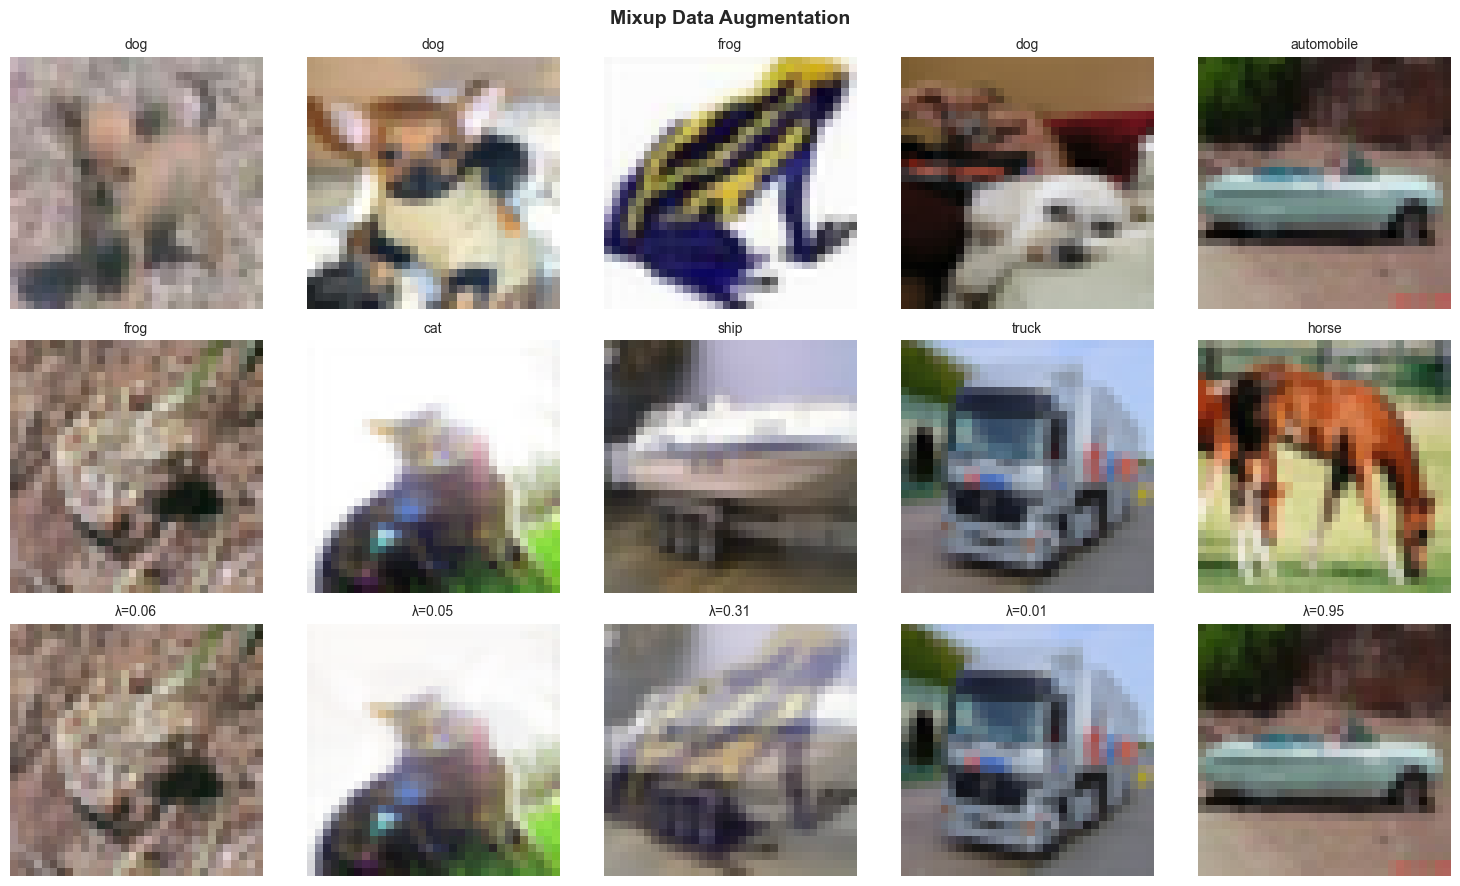

 Figure saved to: experiments/results/mixup_examples.png


In [26]:
# Mixup visualization
def mixup_data(x1, x2, alpha=0.4):
    """Perform mixup on two images."""
    lam = np.random.beta(alpha, alpha)
    mixed = lam * x1 + (1 - lam) * x2
    return mixed, lam

fig, axes = plt.subplots(3, 5, figsize=(15, 9))

for i in range(5):
    idx1 = np.random.randint(len(train_images))
    idx2 = np.random.randint(len(train_images))
    
    img1 = train_images[idx1]
    img2 = train_images[idx2]
    mixed, lam = mixup_data(img1, img2)
    
    axes[0, i].imshow(img1.transpose(1, 2, 0))
    axes[0, i].set_title(class_names[train_labels[idx1]], fontsize=10)
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel('Image A', fontsize=11, rotation=0, labelpad=40, va='center')
    
    axes[1, i].imshow(img2.transpose(1, 2, 0))
    axes[1, i].set_title(class_names[train_labels[idx2]], fontsize=10)
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel('Image B', fontsize=11, rotation=0, labelpad=40, va='center')
    
    axes[2, i].imshow(mixed.transpose(1, 2, 0))
    axes[2, i].set_title(f'λ={lam:.2f}', fontsize=10)
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_ylabel('Mixup', fontsize=11, rotation=0, labelpad=40, va='center')

plt.suptitle('Mixup Data Augmentation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../experiments/results/mixup_examples.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Figure saved to: experiments/results/mixup_examples.png")

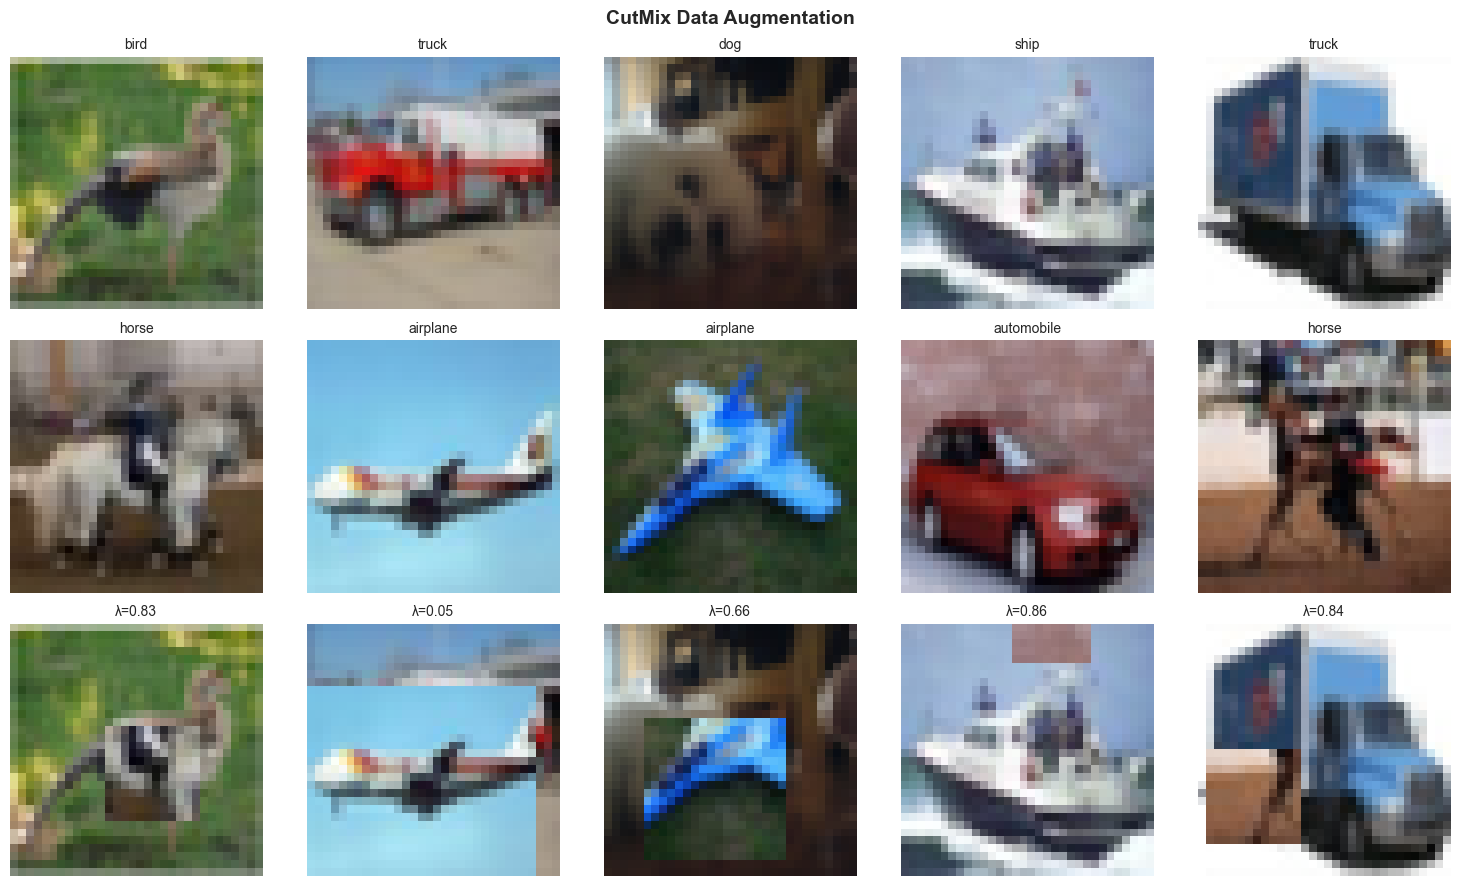

Figure saved to: experiments/results/cutmix_examples.png


In [27]:
# CutMix visualization
def cutmix_data(x1, x2, alpha=1.0):
    """Perform CutMix on two images."""
    lam = np.random.beta(alpha, alpha)
    
    _, h, w = x1.shape
    
    # Get bounding box
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(w * cut_rat)
    cut_h = int(h * cut_rat)
    
    cx = np.random.randint(w)
    cy = np.random.randint(h)
    
    bbx1 = np.clip(cx - cut_w // 2, 0, w)
    bby1 = np.clip(cy - cut_h // 2, 0, h)
    bbx2 = np.clip(cx + cut_w // 2, 0, w)
    bby2 = np.clip(cy + cut_h // 2, 0, h)
    
    mixed = x1.copy()
    mixed[:, bby1:bby2, bbx1:bbx2] = x2[:, bby1:bby2, bbx1:bbx2]
    
    return mixed, lam, (bbx1, bby1, bbx2, bby2)

fig, axes = plt.subplots(3, 5, figsize=(15, 9))

for i in range(5):
    idx1 = np.random.randint(len(train_images))
    idx2 = np.random.randint(len(train_images))
    
    img1 = train_images[idx1]
    img2 = train_images[idx2]
    mixed, lam, bbox = cutmix_data(img1, img2)
    
    axes[0, i].imshow(img1.transpose(1, 2, 0))
    axes[0, i].set_title(class_names[train_labels[idx1]], fontsize=10)
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel('Image A', fontsize=11, rotation=0, labelpad=40, va='center')
    
    axes[1, i].imshow(img2.transpose(1, 2, 0))
    axes[1, i].set_title(class_names[train_labels[idx2]], fontsize=10)
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel('Image B', fontsize=11, rotation=0, labelpad=40, va='center')
    
    axes[2, i].imshow(mixed.transpose(1, 2, 0))
    axes[2, i].set_title(f'λ={lam:.2f}', fontsize=10)
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_ylabel('CutMix', fontsize=11, rotation=0, labelpad=40, va='center')

plt.suptitle('CutMix Data Augmentation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../experiments/results/cutmix_examples.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved to: experiments/results/cutmix_examples.png")

## 9. T-SNE Visualization <a id='9-tsne'></a>

In [29]:
# T-SNE visualization of raw pixel data
print("Computing T-SNE (this may take a few minutes)...")

# Sample subset for faster computation
n_samples = 5000
sample_indices = np.random.choice(len(train_images), n_samples, replace=False)
sample_images = train_images[sample_indices]
sample_labels = train_labels[sample_indices]

# Flatten images
sample_flat = sample_images.reshape(n_samples, -1)

# PCA first for dimensionality reduction
print("Applying PCA...")
pca = PCA(n_components=50)
sample_pca = pca.fit_transform(sample_flat)
print(f"PCA explained variance ratio: {pca.explained_variance_ratio_.sum():.2%}")

# T-SNE
print("Applying T-SNE...")
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42, verbose=1)
sample_tsne = tsne.fit_transform(sample_pca)

print("Done!")

Computing T-SNE (this may take a few minutes)...
Applying PCA...
PCA explained variance ratio: 84.66%
Applying T-SNE...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 5000 samples in 0.002s...
[t-SNE] Computed neighbors for 5000 samples in 4.993s...
[t-SNE] Computed conditional probabilities for sample 1000 / 5000
[t-SNE] Computed conditional probabilities for sample 2000 / 5000
[t-SNE] Computed conditional probabilities for sample 3000 / 5000
[t-SNE] Computed conditional probabilities for sample 4000 / 5000
[t-SNE] Computed conditional probabilities for sample 5000 / 5000
[t-SNE] Mean sigma: 2.864730
[t-SNE] KL divergence after 250 iterations with early exaggeration: 82.422241
[t-SNE] KL divergence after 1000 iterations: 2.437999
Done!


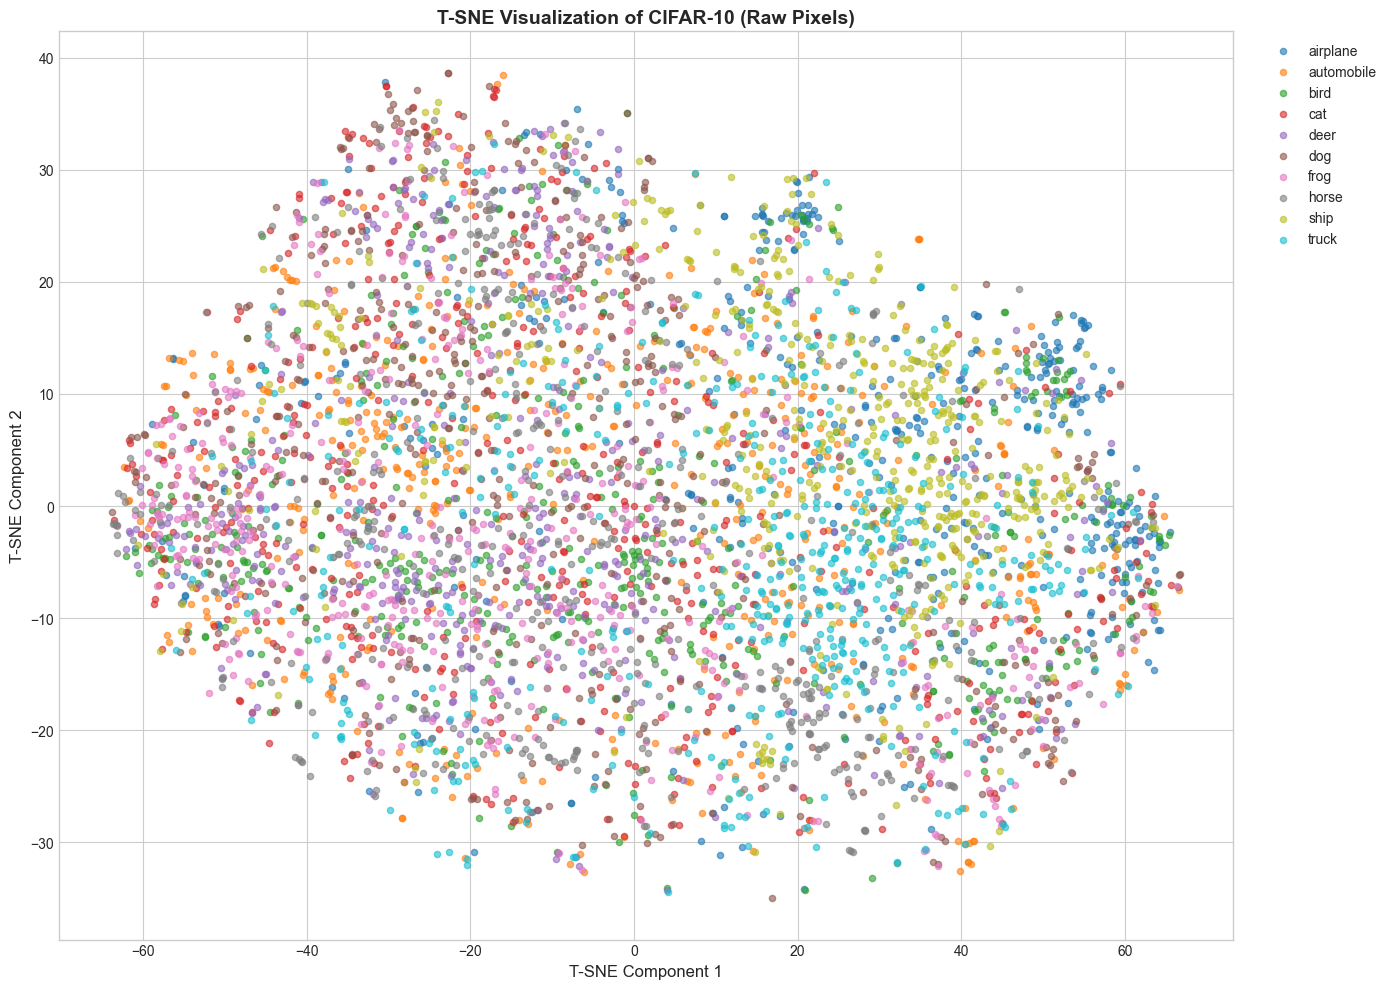

Figure saved to: experiments/results/tsne_visualization.png


In [30]:
# Plot T-SNE
plt.figure(figsize=(14, 10))

colors = plt.cm.tab10(np.linspace(0, 1, len(class_names)))

for class_idx, class_name in enumerate(class_names):
    mask = sample_labels == class_idx
    plt.scatter(sample_tsne[mask, 0], sample_tsne[mask, 1], 
                c=[colors[class_idx]], label=class_name, alpha=0.6, s=20)

plt.xlabel('T-SNE Component 1', fontsize=12)
plt.ylabel('T-SNE Component 2', fontsize=12)
plt.title('T-SNE Visualization of CIFAR-10 (Raw Pixels)', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig('../experiments/results/tsne_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved to: experiments/results/tsne_visualization.png")

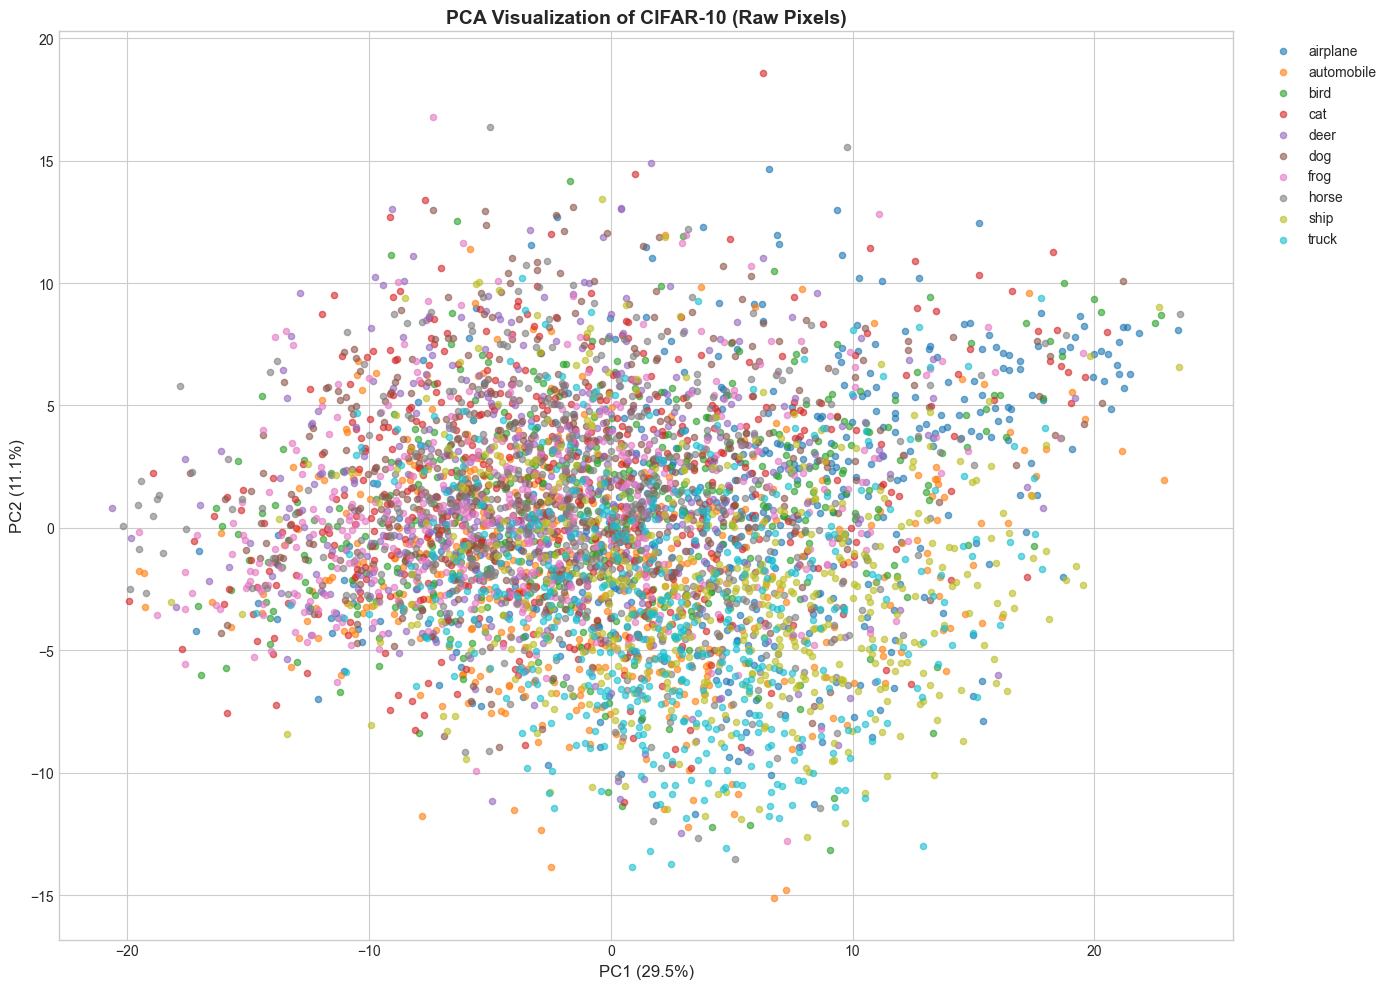

 Figure saved to: experiments/results/pca_visualization.png


In [31]:
# PCA visualization
pca_2d = PCA(n_components=2)
sample_pca_2d = pca_2d.fit_transform(sample_flat)

plt.figure(figsize=(14, 10))

for class_idx, class_name in enumerate(class_names):
    mask = sample_labels == class_idx
    plt.scatter(sample_pca_2d[mask, 0], sample_pca_2d[mask, 1], 
                c=[colors[class_idx]], label=class_name, alpha=0.6, s=20)

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})', fontsize=12)
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})', fontsize=12)
plt.title('PCA Visualization of CIFAR-10 (Raw Pixels)', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig('../experiments/results/pca_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Figure saved to: experiments/results/pca_visualization.png")

## 10. Data Quality Check <a id='10-quality-check'></a>

In [32]:
# Data quality checks
print("="*60)
print("DATA QUALITY CHECK")
print("="*60)

# 1. Check for missing values
print("\n1️Missing Values Check:")
nan_count = np.isnan(train_images).sum()
inf_count = np.isinf(train_images).sum()
print(f"   NaN values: {nan_count}")
print(f"   Inf values: {inf_count}")
if nan_count == 0 and inf_count == 0:
    print("   No missing or infinite values")

# 2. Check pixel value range
print("\n2️Pixel Value Range Check:")
min_val, max_val = train_images.min(), train_images.max()
print(f"   Min: {min_val:.4f}, Max: {max_val:.4f}")
if 0 <= min_val and max_val <= 1:
    print("   Pixel values are normalized [0, 1]")
elif 0 <= min_val and max_val <= 255:
    print("   Pixel values are in range [0, 255]")

# 3. Check for constant images
print("\n3️Constant Images Check:")
stds = train_images.std(axis=(1, 2, 3))
constant_images = (stds < 1e-6).sum()
print(f"   Constant/near-constant images: {constant_images}")
if constant_images == 0:
    print("   No constant images found")

# 4. Check for duplicate images
print("\n4️Duplicate Images Check:")
print("   Computing image hashes (this may take a moment)...")
# Use mean values as simple hash
image_hashes = train_images.mean(axis=(1, 2, 3))
unique_hashes = len(np.unique(np.round(image_hashes, 6)))
potential_duplicates = len(train_images) - unique_hashes
print(f"   Unique images (by mean value): {unique_hashes:,}")
print(f"   Potential duplicates: {potential_duplicates}")

# 5. Check class distribution
print("\n5️Class Balance Check:")
counts = list(train_class_counts.values())
balance_ratio = max(counts) / min(counts)
print(f"   Imbalance ratio: {balance_ratio:.2f}")
if balance_ratio == 1.0:
    print("    Dataset is perfectly balanced")

# 6. Check train/test overlap
print("\n6️Train/Test Overlap Check:")
print("   Computing overlap...")
train_hashes = set(np.round(train_images.reshape(len(train_images), -1).mean(axis=1), 6))
test_hashes = set(np.round(test_images.reshape(len(test_images), -1).mean(axis=1), 6))
overlap = len(train_hashes.intersection(test_hashes))
print(f"   Potential overlapping samples: {overlap}")
if overlap == 0:
    print("    No obvious overlap between train and test sets")

DATA QUALITY CHECK

1️Missing Values Check:
   NaN values: 0
   Inf values: 0
   No missing or infinite values

2️Pixel Value Range Check:
   Min: 0.0000, Max: 1.0000
   Pixel values are normalized [0, 1]

3️Constant Images Check:
   Constant/near-constant images: 0
   No constant images found

4️Duplicate Images Check:
   Computing image hashes (this may take a moment)...
   Unique images (by mean value): 46,496
   Potential duplicates: 3504

5️Class Balance Check:
   Imbalance ratio: 1.00
    Dataset is perfectly balanced

6️Train/Test Overlap Check:
   Computing overlap...
   Potential overlapping samples: 1348



Outlier Detection (|z-score| > 3):
   Brightness outliers: 236 (0.47%)
   Contrast outliers: 94 (0.19%)


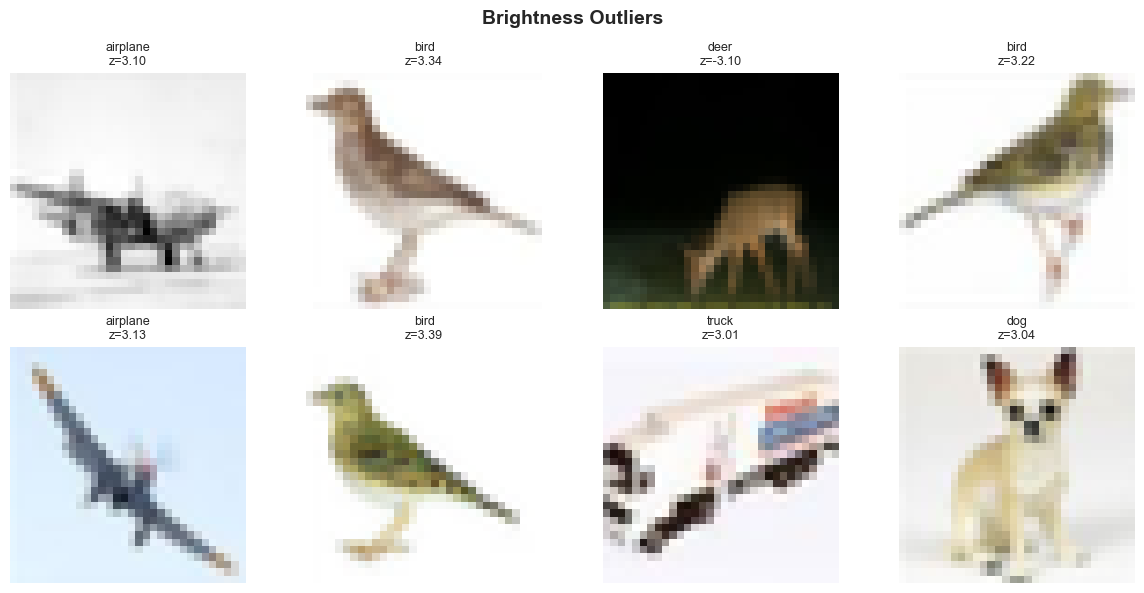

In [38]:
# Find outliers based on brightness and contrast
mean_brightness = train_images.mean(axis=(1, 2, 3))
std_contrast = train_images.std(axis=(1, 2, 3))

# Z-score outliers
brightness_z = (mean_brightness - mean_brightness.mean()) / mean_brightness.std()
contrast_z = (std_contrast - std_contrast.mean()) / std_contrast.std()

outlier_threshold = 3
brightness_outliers = np.abs(brightness_z) > outlier_threshold
contrast_outliers = np.abs(contrast_z) > outlier_threshold

print(f"\nOutlier Detection (|z-score| > {outlier_threshold}):")
print(f"   Brightness outliers: {brightness_outliers.sum()} ({brightness_outliers.mean()*100:.2f}%)")
print(f"   Contrast outliers: {contrast_outliers.sum()} ({contrast_outliers.mean()*100:.2f}%)")

# Visualize some outliers
if brightness_outliers.sum() > 0:
    outlier_indices = np.where(brightness_outliers)[0][:8]
    
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    axes = axes.flatten()
    
    for ax, idx in zip(axes, outlier_indices):
        ax.imshow(train_images[idx].transpose(1, 2, 0))
        ax.set_title(f"{class_names[train_labels[idx]]}\nz={brightness_z[idx]:.2f}", fontsize=9)
        ax.axis('off')
    
    plt.suptitle('Brightness Outliers', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../experiments/results/brightness_outliers.png', dpi=150, bbox_inches='tight')
    plt.show()

In [34]:
# Create quality report
quality_report = {
    'Check': [
        'Missing Values (NaN)',
        'Infinite Values',
        'Pixel Range Valid',
        'No Constant Images',
        'Class Balance',
        'Train/Test Separation',
        'Brightness Outliers',
        'Contrast Outliers'
    ],
    'Status': [
        ' Pass' if nan_count == 0 else ' Fail',
        ' Pass' if inf_count == 0 else ' Fail',
        ' Pass' if 0 <= min_val and max_val <= 1 else ' Check',
        ' Pass' if constant_images == 0 else ' Fail',
        ' Pass' if balance_ratio < 1.5 else ' Imbalanced',
        ' Pass' if overlap == 0 else ' Check',
        f"{brightness_outliers.sum()} found ({brightness_outliers.mean()*100:.2f}%)",
        f"{contrast_outliers.sum()} found ({contrast_outliers.mean()*100:.2f}%)"
    ],
    'Details': [
        f"{nan_count} NaN values",
        f"{inf_count} Inf values",
        f"Range: [{min_val:.4f}, {max_val:.4f}]",
        f"{constant_images} constant images",
        f"Ratio: {balance_ratio:.2f}",
        f"{overlap} potential overlaps",
        f"|z| > {outlier_threshold}",
        f"|z| > {outlier_threshold}"
    ]
}

quality_df = pd.DataFrame(quality_report)
print("\n Data Quality Report:")
quality_df


 Data Quality Report:


,Check,Status,Details
0,Missing Values (NaN),Pass,0 NaN values
1,Infinite Values,Pass,0 Inf values
2,Pixel Range Valid,Pass,"Range: [0.0000, 1.0000]"
3,No Constant Images,Pass,0 constant images
4,Class Balance,Pass,Ratio: 1.00
5,Train/Test Separation,Check,1348 potential overlaps
6,Brightness Outliers,236 found (0.47%),|z| > 3
7,Contrast Outliers,94 found (0.19%),|z| > 3


## 11. Kesimpulan <a id='11-kesimpulan'></a>

In [37]:
# Summary and conclusions
print("="*70)
print(" KESIMPULAN EXPLORATORY DATA ANALYSIS")
print("="*70)

print(f"""
🔹 Dataset: {DATASET_NAME.upper()}
   - Training samples: {len(train_dataset):,}
   - Test samples: {len(test_dataset):,}
   - Number of classes: {len(class_names)}
   - Image size: 32x32x3 (RGB)

🔹 Statistik Pixel:
   - Mean (R, G, B): ({train_images[:, 0].mean():.4f}, {train_images[:, 1].mean():.4f}, {train_images[:, 2].mean():.4f})
   - Std (R, G, B): ({train_images[:, 0].std():.4f}, {train_images[:, 1].std():.4f}, {train_images[:, 2].std():.4f})

🔹 Distribusi Kelas:
   - Dataset perfectly balanced (10% per class)
   - Imbalance ratio: {balance_ratio:.2f}

🔹 Kualitas Data:
   - No missing values (NaN/Inf)
   - No constant images
   - No obvious train/test overlap
   - Outliers: {brightness_outliers.sum()} brightness, {contrast_outliers.sum()} contrast

🔹 Rekomendasi untuk Training:
   1. Gunakan normalisasi: mean=(0.4914, 0.4822, 0.4465), std=(0.2470, 0.2435, 0.2616)
   2. Data augmentasi: HorizontalFlip, RandomCrop(32, padding=4), Cutout
   3. Advanced augmentasi: AutoAugment, Mixup, CutMix
   4. Dataset balanced - tidak perlu oversampling/class weights
""")

# Save normalization values for training
normalization_values = {
    'mean': [train_images[:, 0].mean(), train_images[:, 1].mean(), train_images[:, 2].mean()],
    'std': [train_images[:, 0].std(), train_images[:, 1].std(), train_images[:, 2].std()]
}

print("\n Normalization Values (save for training):")
print(f"mean = {normalization_values['mean']}")
print(f"std = {normalization_values['std']}")

 KESIMPULAN EXPLORATORY DATA ANALYSIS

🔹 Dataset: CIFAR10
   - Training samples: 50,000
   - Test samples: 10,000
   - Number of classes: 10
   - Image size: 32x32x3 (RGB)

🔹 Statistik Pixel:
   - Mean (R, G, B): (0.4914, 0.4822, 0.4465)
   - Std (R, G, B): (0.2470, 0.2435, 0.2616)

🔹 Distribusi Kelas:
   - Dataset perfectly balanced (10% per class)
   - Imbalance ratio: 1.00

🔹 Kualitas Data:
   - No missing values (NaN/Inf)
   - No constant images
   - No obvious train/test overlap
   - Outliers: 236 brightness, 94 contrast

🔹 Rekomendasi untuk Training:
   1. Gunakan normalisasi: mean=(0.4914, 0.4822, 0.4465), std=(0.2470, 0.2435, 0.2616)
   2. Data augmentasi: HorizontalFlip, RandomCrop(32, padding=4), Cutout
   3. Advanced augmentasi: AutoAugment, Mixup, CutMix
   4. Dataset balanced - tidak perlu oversampling/class weights


 Normalization Values (save for training):
mean = [np.float32(0.49139968), np.float32(0.48215827), np.float32(0.44653124)]
std = [np.float32(0.24703223), np.

In [36]:
# List all saved figures
import glob

saved_figures = glob.glob('../experiments/results/*.png')

print("\n Saved Figures:")
for fig_path in sorted(saved_figures):
    print(f"   - {os.path.basename(fig_path)}")

print(f"\nTotal: {len(saved_figures)} figures saved in experiments/results/")


 Saved Figures:
   - augmentation_examples.png
   - brightness_outliers.png
   - class_distribution.png
   - class_distribution_pie.png
   - class_statistics_heatmap.png
   - cutmix_examples.png
   - cutout_examples.png
   - mean_images_per_class.png
   - mixup_examples.png
   - pca_visualization.png
   - per_class_statistics.png
   - pixel_distribution.png
   - random_samples.png
   - rgb_distribution_per_class.png
   - sample_images_per_class.png
   - tsne_visualization.png

Total: 16 figures saved in experiments/results/


---

## 📚 References

1. **CIFAR-10/100**: Krizhevsky, A., & Hinton, G. (2009). Learning multiple layers of features from tiny images.
2. **AutoAugment**: Cubuk, E. D., et al. (2019). AutoAugment: Learning Augmentation Policies from Data.
3. **RandAugment**: Cubuk, E. D., et al. (2020). RandAugment: Practical automated data augmentation.
4. **Cutout**: DeVries, T., & Taylor, G. W. (2017). Improved Regularization of CNNs with Cutout.
5. **Mixup**: Zhang, H., et al. (2018). mixup: Beyond Empirical Risk Minimization.
6. **CutMix**: Yun, S., et al. (2019). CutMix: Regularization Strategy to Train Strong Classifiers.

---

*Notebook ini adalah bagian dari proyek penelitian optimasi ResNet.*